In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid, cumulative_trapezoid
from scipy.interpolate import CubicSpline
from scipy.stats import norm, lognorm

# Cinética de Procesos (Sesión 05)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# 1. Introducción

## 1.1 Consideraciones

Una de las hipótesis fuertes en la construcción de los conceptos de reactores ideales (batch, CSTR, PFR, etc.) es que el mezclado es perfecto. En el mundo real este no es el caso.

## 1.2 Distribución de Tiempos de Residencia (RTD)

### 1.2.1 Tiempo de residencia

**El tiempo de residencia, es el tiempo que pasan los átomos (constituyentes de las especies químicas) en un reactor.**

### 1.2.2 Función de Distribución de Tiempos de Residencia (RTD)

**Reactores Batch / PFR:**

El tiempo de residencia es el mismo para todos los átomos. Esto es, la distribución de tiempo de residencia tiene forma de una delta de Dirac.

- En un reactor Batch todos los átomos se cargan en una operación unitaria, igualmente la descarga.
- En un reactor PFR, todos los átomos a la salida del reactor han estado el mismo tiempo en el reactor.

**Otros reactores:**

El tiempo de residencia no es el mismo para todos los átomos. Esto es, existe una distribución de tiempos de residencia, que se puede medir.

- En un reactor CSTR, la alimentación se mezcla instantaneamente en el reactor al mismo tiempo que se evacúa el reactor, i.e., algunos átomos pasan mas o menos tiempo en el reactor.

## 1.3 Construcción de curvas RTD

La distribución de tiempos de residencia se estima a partir de resultados de experimentos de inyección de trazadores. Las dos condiciones asintóticas de inyección de un trazador corresponden a la inyección en pulso y a la inyección continua.

### 1.3.1 Inyección de un trazador en pulso

**Experimento:**

Una cantidad de trazador, $N_0$ se inyecta de forma rápida al flujo de entrada del reactor. La concentración del trazador a la salida del reactor se mide en función del tiempo.

**Curva C:**

En análisis RTD, la curva C es aquella que representa la concentración del trazador inyectado en pluso en el efluente del reactor vs tiempo, i.e., $C$ vs $t$.

Las características de la curva C dependen del tipo de reactor:

- En un reactor PFR se observará un pulso en $C$ cuando $t=\tau$.

- En un reactor CSTR, el trazador se mezcla instantaneamente, por lo que se observará una disminución exponencial de $C$ al transcurrir el tiempo.

- En un reactor real (RR), las distribuciones serán diferentes.

$$\tau = \frac{V}{\dot{Q}}$$

<details>
<summary><b>Nomenclatura</b></summary>

<div class="alert alert-info">

- **$\tau$**: tiempo espacial, $[\mathrm{s}]$.

- **$V$**: Volumen del reactor, $[\mathrm{m^{3}}]$.

- **$\dot{Q}$**: Flujo volumétrico, $[\mathrm{m^3.s^{-1}}]$.


</div>

</details>

**Curva E:**

La distribución de tiempos de residencia, $E(t)$, representa la fracción de todo material que reside en el reactor a un periodo de tiempo dado. Está definida como:

$$E(t) = \frac{\displaystyle C(t)}{\displaystyle \int_{0}^{\infty} C(t) dt}$$

$$\int_{0}^{\infty} E(t) dt = 1$$



### 1.3.2 Inyección continua de un trazador

**Experimento:**


Un trazador se inyecta a la entrada de un reactor con un flujo molar continuo $F_{0}$. La concentración del trazador a la salida del reactor se mide en función del tiempo.

**Curva F:**

En análisis RTD, la curva F es aquella que representa la concentración normalizada del trazador inyectado en continuo en el efluente del reactor vs tiempo, i.e., $F$ vs $t$.


$$F(t) = \frac{C(t)}{C_{0}} = \frac{C(t)}{F_{0} / \dot{Q}}$$

Las características de la curva F dependen del tipo de reactor:

- En un reactor PFR se observará un escalón en $C$ cuando $t=\tau$.

- En un reactor CSTR, el trazador se mezcla instantaneamente, por lo que se observará un aumento exponencial de $C$.

- En un reactor real (RR), las distribuciones serán diferentes.

$$\tau = \frac{V}{\dot{Q}}$$

**Curva E:**

La distribución de tiempos de residencia, $E(t)$, representa la fracción de todo material que reside en el reactor a un periodo de tiempo dado. Está definida como:

$$E(t) = \frac{dF(t)}{dt}$$

$$\int_{0}^{\infty} E(t) dt = 1$$



<details>
<summary><b>Nomenclatura</b></summary>

<div class="alert alert-info">

- **$C_0$**: Concentración de trazador a la entrada del reactor, $[\mathrm{mol.m^{-3}}]$.

- **$F_0$**: Flujo molar de trazador a la entrada del reactor, $[\mathrm{mol.s^{-1}}]$.

- **$\tau$**: tiempo espacial, $[\mathrm{s}]$.

- **$V$**: Volumen del reactor, $[\mathrm{m^{3}}]$.

- **$\dot{Q}$**: Flujo volumétrico, $[\mathrm{m^3.s^{-1}}]$.


</div>

</details>

<details>
<summary><b>Nomenclatura</b></summary>

<div class="alert alert-info">

- **$\tau$**: tiempo espacial, $[\mathrm{s}]$.

- **$V$**: Volumen del reactor, $[\mathrm{m^{3}}]$.

- **$\dot{Q}$**: Flujo volumétrico, $[\mathrm{m^3.s^{-1}}]$.


</div>

</details>

## 1.4 Ejemplos

### 1.4.1 Ejemplo 

    Fogler, Ex. 16.1

Se inyecta un pulso de trazador a un reactor a $320$ $\mathrm{K}$, y se mide su concentración en el efluente en función del tiempo. Los datos recolectados se muestran debajo.

In [24]:
t = np.array([0, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14]) # min
C = np.array([0, 0.6, 1.4, 5, 8, 10, 8, 6, 4, 3, 2.2, 1.5, 0.6, 0]) # g/m3

Construya figuras mostrando $C(t)$ vs $t$, $E(t)$ vs $t$, y $F(t)$ vs $t$.

**Integración numérica:**

∫ C(t)dt = 51.0000
∫ E(t)dt = 1.0000


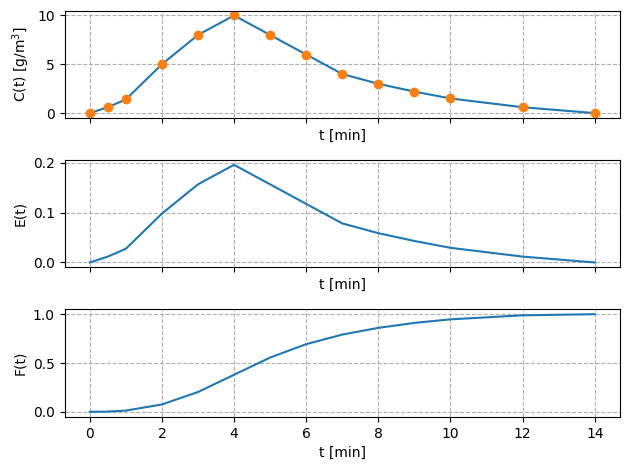

In [25]:
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, sharex=True)
# Curva C(t)
ax0.plot(t, C)
ax0.plot(t, C, marker='o', ls='')
ax0.set_ylabel(r"C(t) [g/m$^3$]")
# Curva E(t)
integral = trapezoid(C, t)
E = C / integral # E(t)
print(f"∫ C(t)dt = {integral:.4f}")
print(f"∫ E(t)dt = {trapezoid(E,t):.4f}")
ax1.plot(t, E)
ax1.set_ylabel(r"E(t)")
# Curva F(t)
F = cumulative_trapezoid(E, t, initial=0)
ax2.plot(t, F)
ax2.set_ylabel(r"F(t)")
for ax in (ax0, ax1, ax2):
    ax.set_xlabel(r"t [min]")
    ax.grid(ls='--')
fig.tight_layout()
plt.show()

**Interpolación e integración:**

∫ C(t)dt = 51.1370
∫ E(t)dt = 1.0000


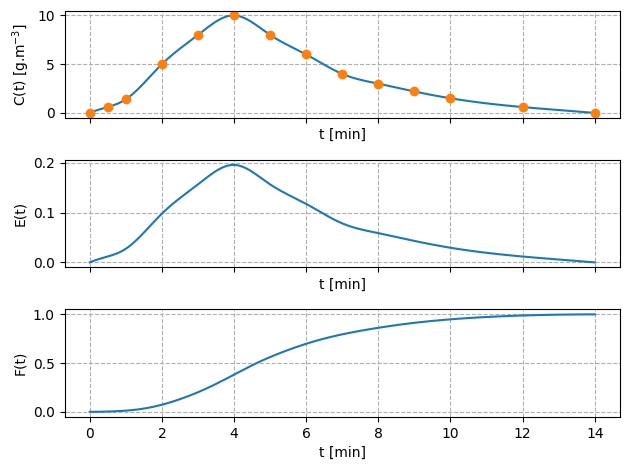

In [26]:
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, sharex=True)
tint = np.linspace(0, 14, 200)
# Curva C(t)
cs = CubicSpline(t, C)              # C(t) spline
ax0.plot(tint, cs(tint))
ax0.plot(t, C, marker='o', ls='')
ax0.set_ylabel(r"C(t) [g.m$^{-3}$]")
# Curva E(t)
integral = cs.integrate(t[0], t[-1])
E = C / integral                    # E(t)
es = CubicSpline(t, C/integral)     # E(t) spline
print(f"∫ C(t)dt = {integral:.4f}")
print(f"∫ E(t)dt = {es.integrate(tint[0], tint[-1]):.4f}")
ax1.plot(tint, es(tint))
ax1.set_ylabel(r"E(t)")
# Curva F(t)
fs = es.antiderivative()            # F(t) spline
ax2.plot(tint, fs(tint))
ax2.set_ylabel(r"F(t)")
for ax in (ax0, ax1, ax2):
    ax.set_xlabel(r"t [min]")
    ax.grid(ls='--')
fig.tight_layout()
plt.show()

### 1.4.2 Ejemplo

    Levenspiel, Ex. 11.1

In [27]:
t = np.array([0, 5, 10, 15, 20, 25, 30, 35]) # min
C = np.array([0, 3, 5, 5, 4, 2, 1, 0]) # g/dm3

**Integración numérica:**

∫ C(t)dt = 100.0000
∫ E(t)dt = 1.0000


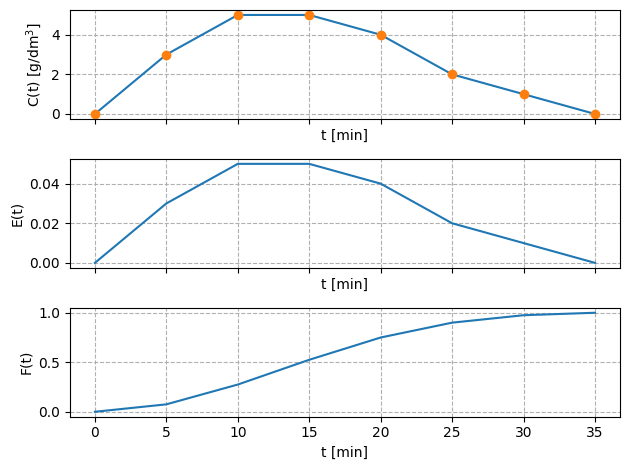

In [28]:
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, sharex=True)
# Curva C(t)
ax0.plot(t, C)
ax0.plot(t, C, marker='o', ls='')
ax0.set_ylabel(r"C(t) [g/dm$^3$]")
# Curva E(t)
integral = trapezoid(C, t)
E = C / integral # E(t)
print(f"∫ C(t)dt = {integral:.4f}")
print(f"∫ E(t)dt = {trapezoid(E,t):.4f}")
ax1.plot(t, E)
ax1.set_ylabel(r"E(t)")
# Curva F(t)
F = cumulative_trapezoid(E, t, initial=0)
ax2.plot(t, F)
ax2.set_ylabel(r"F(t)")
for ax in (ax0, ax1, ax2):
    ax.set_xlabel(r"t [min]")
    ax.grid(ls='--')
fig.tight_layout()
plt.show()

**Interpolación e integración:**

∫ C(t)dt = 101.9189
∫ E(t)dt = 1.0000


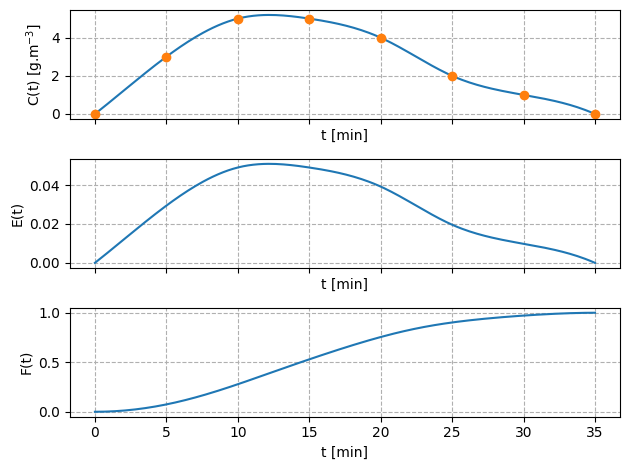

In [29]:
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, sharex=True)
tint = np.linspace(0, 35, 200)
# Curva C(t)
cs = CubicSpline(t, C)              # C(t) spline
ax0.plot(tint, cs(tint))
ax0.plot(t, C, marker='o', ls='')
ax0.set_ylabel(r"C(t) [g.m$^{-3}$]")
# Curva E(t)
integral = cs.integrate(t[0], t[-1])
E = C / integral                    # E(t)
es = CubicSpline(t, C/integral)     # E(t) spline
print(f"∫ C(t)dt = {integral:.4f}")
print(f"∫ E(t)dt = {es.integrate(tint[0], tint[-1]):.4f}")
ax1.plot(tint, es(tint))
ax1.set_ylabel(r"E(t)")
# Curva F(t)
fs = es.antiderivative()            # F(t) spline
ax2.plot(tint, fs(tint))
ax2.set_ylabel(r"F(t)")
for ax in (ax0, ax1, ax2):
    ax.set_xlabel(r"t [min]")
    ax.grid(ls='--')
fig.tight_layout()
plt.show()

### 1.4.3 Uso razonable de la interpolación



<div class="alert alert-warning">

$$\text{Interpolación } \ne \text{ Extrapolación}$$

</div>


    Fogler, Ex. 16.1

               ∫[0,14]   ∫[0,20]
not-a-knot     1.0000    0.7890
periodic       0.9920    1.6898
clamped        0.9972    1.6340
natural        0.9996    0.8689


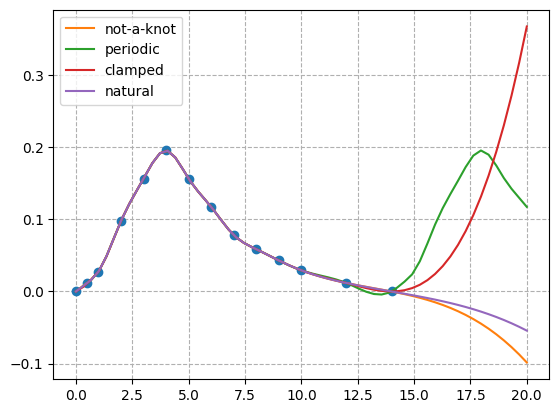

In [30]:
t = np.array([0, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14]) # min
C = np.array([0, 0.6, 1.4, 5, 8, 10, 8, 6, 4, 3, 2.2, 1.5, 0.6, 0]) # g/m3
integral = CubicSpline(t, C) .integrate(t[0], t[-1])

fig, ax = plt.subplots()
ax.plot(t, C/integral, ls='', marker='o')
tt = np.linspace(0, 20, 60)

print(14*" ", "∫[0,14]  ", "∫[0,20]")
bc_types = ["not-a-knot", "periodic", "clamped", "natural"]
for bc_type in bc_types:
    Es = CubicSpline(t, C/integral, bc_type=bc_type)     # E(t) spline
    ax.plot(tt, Es(tt), label=f'{bc_type}')
    print(f"{bc_type:14} {Es.integrate(0, 14):.4f}    {Es.integrate(0, 20):.4f}")
ax.grid(ls='--')
ax.legend()
plt.show()

    Levenspiel, Ex. 11.1

               ∫[0,35]   ∫[0,60]
not-a-knot     1.0000    0.9391
periodic       0.9812    1.0455
clamped        0.9812    1.0228
natural        0.9984    0.9728


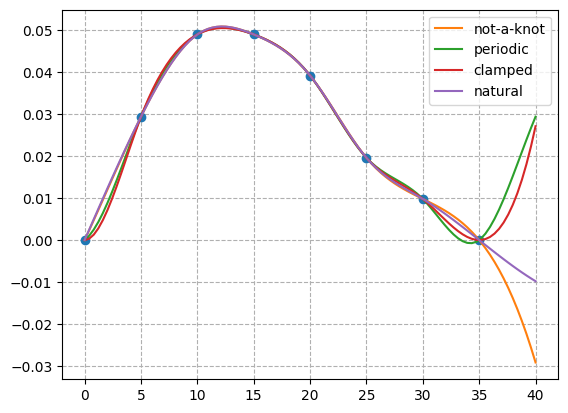

In [35]:
t = np.array([0, 5, 10, 15, 20, 25, 30, 35]) # min
C = np.array([0, 3, 5, 5, 4, 2, 1, 0]) # g/dm3
integral = CubicSpline(t, C) .integrate(t[0], t[-1])

fig, ax = plt.subplots()
ax.plot(t, C/integral, ls='', marker='o')
tt = np.linspace(0, 40, 100)

print(14*" ", "∫[0,35]  ", "∫[0,60]")
bc_types = ["not-a-knot", "periodic", "clamped", "natural"]
for bc_type in bc_types:
    Es = CubicSpline(t, C/integral, bc_type=bc_type)     # E(t) spline
    ax.plot(tt, Es(tt), label=f'{bc_type}')
    print(f"{bc_type:14} {Es.integrate(0, 35):.4f}    {Es.integrate(0, 40):.4f}")
ax.grid(ls='--')
ax.legend()
plt.show()